In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Churn_Modelling.csv')
print("Datos cargados:", df.shape)

Datos cargados: (10000, 14)


In [10]:
# Eliminar columnas que no aportan
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("Gender encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print(df.columns.tolist())

df.shape

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


(10000, 12)

In [12]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Churn en train:", y_train.mean().round(2))
print("Churn en test:", y_test.mean().round(2))

Train: (8000, 11)
Test: (2000, 11)
Churn en train: 0.2
Churn en test: 0.2


In [21]:
# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1: Regresión Logística
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))


=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

AUC-ROC: 0.7747778595236223


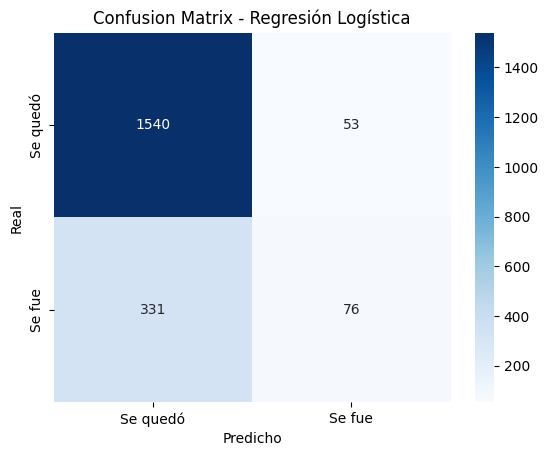

AUC-ROC: 0.7747778595236223


In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se quedó', 'Se fue'],
            yticklabels=['Se quedó', 'Se fue'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Confusion Matrix - Regresión Logística')
plt.show()

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

AUC-ROC: 0.8542618118889306
